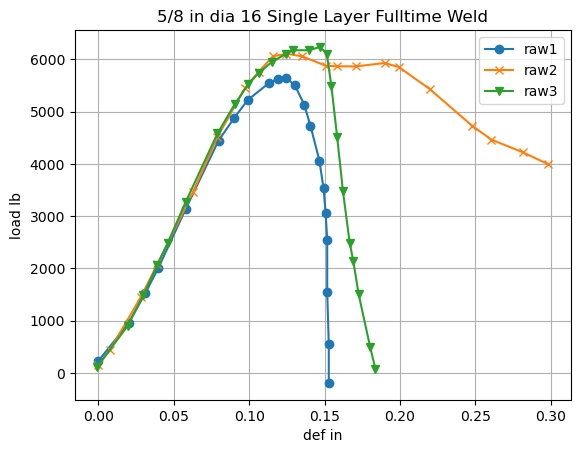

In [43]:
import math as m
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

raw1 =np.array([
    [0.0, 700.636942675158],
    [0.020099009900990103, 1426.751592356687],
    [0.031188118811881174, 1999.999999999999],
    [0.039851485148514845, 2484.0764331210194],
    [0.05787128712871285, 3605.0955414012733],
    [0.07970297029702968, 4917.197452229299],
    [0.09009900990099008, 5350.3184713375795],
    [0.0991089108910891, 5694.267515923567],
    [0.11297029702970297, 6012.738853503184],
    [0.11886138613861384, 6101.910828025478],
    [0.12475247524752474, 6114.649681528663],
    [0.1302970297029703, 5974.522292993631],
    [0.1365346534653465, 5605.095541401273],
    [0.14069306930693065, 5197.452229299362],
    [0.14658415841584155, 4535.031847133758],
    [0.14935643564356432, 3999.999999999999],
    [0.1507425742574257, 3528.662420382165],
    [0.15178217821782175, 3006.369426751592],
    [0.15178217821782175, 2012.7388535031841],
    [0.1528217821782178, 1019.1082802547762],
    [0.1528217821782178, 280.2547770700621]
])

raw2 = np.array([
    [0.0, 700.636942675158],
    [0.007623762376237617, 993.630573248407],
    [0.028069306930693066, 1999.999999999999],
    [0.03915841584158415, 2636.9426751592346],
    [0.06272277227722771, 4012.738853503184],
    [0.07900990099009898, 5070.0636942675155],
    [0.09737623762376234, 6012.738853503184],
    [0.10638613861386138, 6318.471337579618],
    [0.11574257425742575, 6611.464968152866],
    [0.12475247524752474, 6662.420382165605],
    [0.1351485148514851, 6611.464968152866],
    [0.1507425742574257, 6433.121019108281],
    [0.15836633663366334, 6420.382165605095],
    [0.17118811881188117, 6420.382165605095],
    [0.18990099009900985, 6484.076433121019],
    [0.1992574257425742, 6407.643312101911],
    [0.21970297029702968, 5987.261146496815],
    [0.24777227722772271, 5286.624203821655],
    [0.26059405940594055, 5019.108280254777],
    [0.28138613861386136, 4777.070063694267],
    [0.2983663366336633, 4547.770700636942]
])

raw3 = np.array([
    [-0.0006930693069306937, 624.2038216560495],
    [0.01940594059405941, 1401.2738853503179],
    [0.029801980198019787, 1987.261146496815],
    [0.03915841584158415, 2573.248407643312],
    [0.046089108910891075, 2993.630573248407],
    [0.05787128712871285, 3770.7006369426745],
    [0.07900990099009898, 5082.802547770701],
    [0.09044554455445543, 5643.312101910828],
    [0.09945544554455442, 6025.477707006369],
    [0.10638613861386138, 6242.03821656051],
    [0.11539603960396037, 6458.598726114649],
    [0.12475247524752474, 6611.464968152866],
    [0.12925742574257426, 6675.15923566879],
    [0.1396534653465346, 6675.15923566879],
    [0.1469306930693069, 6738.853503184713],
    [0.1514356435643564, 6611.464968152866],
    [0.15455445544554453, 5987.261146496815],
    [0.15836633663366334, 5019.108280254777],
    [0.16217821782178216, 3987.261146496815],
    [0.16668316831683166, 2993.630573248407],
    [0.1691089108910891, 2636.9426751592346],
    [0.17257425742574256, 2012.7388535031841],
    [0.18019801980198014, 1006.3694267515912],
    [0.1836633663366336, 585.9872611464962]
])

x1= raw1[:,0]
y1 = raw1[:,1]-469.69696969697
x2= raw2[:,0]
y2 = raw2[:,1]-553.0303030303039
x3= raw3[:,0]
y3 = raw3[:,1]-500.0
plt.figure()
plt.plot(x1,y1,marker='o',label="raw1")
plt.plot(x2,y2,marker='x',label="raw2")
plt.plot(x3,y3,marker='v',label="raw3")
plt.ylabel('load lb')
plt.xlabel('def in')
plt.title("5/8 in dia 16 Single Layer Fulltime Weld")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
def support_group(n_col, n_row, col_spacing, row_spacing):
    x_support = []
    y_support = []
    for i in range(n_col):
        for j in range(n_row):
            x_support.append(i * col_spacing - (n_col - 1) * col_spacing / 2)
            y_support.append(j * row_spacing - (n_row - 1) * row_spacing / 2)
    return x_support, y_support

In [47]:
def force_from_curve(delta_i, delta_tab,force_tab, normalize_by = None):
    # castining deformations and force values into numpy arrays b/c NumPy arrays let us do fast, vectorized math
    delta_tab = np.asarray(delta_tab,dtype=float) 
    force_tab = np.asarray(force_tab,dtype=float)
    x = np.asarray(delta_tab, float)
    y = np.asarray(force_tab, float)

    #cliping delta values to the range using clipping If value < min_val, it gets replaced by min_val. Same is true the other way
    xi = np.clip(np.asarray(delta_i, float), x.min(), x.max()) #so if delta_i is < minimum deformation it is xmin (same for xmax), this is b/c We don’t want to interpolate outside the tabulated data range. 
    f = np.interp(xi, x, y)              # capped interpolation
    f = np.clip(f, 0.0, y.max())         # guard against tiny numeric overshoots, f < 0.0 → set it to 0., If f > y.max() → set it to y.max().
    if normalize_by is not None:
        f = np.clip(f / float(normalize_by), 0.0, 1.0) # we are making sure Makes sure normalized FORCE results are always between 0 and 1. We use this
        # if we normalize by pf_arc
    return f

In [49]:
def ICM1(x_load, y_load, x_coord, y_coord, fastener_types, ArcDataLabel, screw_params,delta_max,lamda):
    x_centroid, y_centroid = np.mean(x_coord), np.mean(y_coord)
    n = len(x_coord)

    
    raw = curves[ArcDataLabel]
    delta_tab = raw[:, 0]
    force_tab = raw[:, 1] / 1000
    P_f_arc = max(raw[:, 1]) / 1000  # corrected (was raw1)
    

    Ke, Ks, Kc, Kr = screw_params['Ke'], screw_params['Ks'], screw_params['Kc'], screw_params['Kr']
    dy, dc, dr, df_screw = screw_params['dy'], screw_params['dc'], screw_params['dr'], screw_params['df']
    Fc = screw_params['Fc']  # peak force for normalization

    # ---------- LOAD SETUP ----------
    hori_angle = 0
    vert_angle = 90 - hori_angle
    Py, Px = (-1.0 * m.cos(vert_angle * (m.pi / 180)), m.sin(vert_angle * (m.pi / 180)))  # kips (Py < 0 means downward)
    Mo = Py * x_load - Px * y_load  # kip-in, moment about centroid

    # ---------- POLAR MOMENT ----------
    J = ((x_coord - x_centroid)**2 + (y_coord - y_centroid)**2).sum()
    
    # ---------- INITIAL ELASTIC IC GUESS ----------
    x_ic = x_centroid + (-Py * J) / (n * Mo)
    y_ic = y_centroid + (Px * J) / (n * Mo)

    # ---------- ITERATION PARAMETERS ----------
    threshold = 1e-3
    F = np.inf
    max_iter = 200
    eps = 1e-12  # for safe division

   # ---------- ITERATION LOOP ----------
    for it in range(max_iter):
        # Compute applied moment about current IC
        Mp = Py * (x_load - x_ic) - Px * (y_load - y_ic)

        # Build DataFrame for this iteration
        df = pd.DataFrame({
        'x_coordinate': x_coord, 'y_coordinate': y_coord, 'Fastener type': fastener_types}, index=[f"Fastener {i}" for i in range(1, n + 1)])
        df['dx'] = df['x_coordinate'] - x_ic
        df['dy'] = df['y_coordinate'] - y_ic
        df['d'] = np.sqrt(df['dx']**2 + df['dy']**2)

        
# Computing deformation component _______________________________________________
        df['ux'] = df['dx'] / (df['d'] + eps)
        df['uy'] = df['dy'] / (df['d'] + eps)

        # unit tangential direction (perpendicular to radial)
        df['tx'] = -df['uy']
        df['ty'] =  df['ux']

        # choose theta so that max slip magnitude equals delta_max
        theta = delta_max / (df['d'].max() + eps)

        # tangential slip vector components (this is the deformation direction in ICM)
        df['delta_x'] = theta * df['d'] * df['tx']
        df['delta_y'] = theta * df['d'] * df['ty']

        # slip magnitude (what you were using before)
        df['delta'] = np.hypot(df['delta_x'], df['delta_y'])

        def get_force_components(row):
            alpha_y = 0
            t = row['Fastener type']
        
            # normalized force ratio based on slip magnitude
            if t in ('InteriorArc', 'EndArc', 'EdgeArc'):
                r = force_from_curve(row['delta'], delta_tab, force_tab, normalize_by=P_f_arc)
            # apply efficiency
                if t == 'EndArc':
                    r *= lamda
                elif t == 'EdgeArc':
                    r *= lamda

            
            elif t == 'SideScrew':
                r = screw_force(row['delta'], Ke, Ks, Kc, Kr, dy, dc, dr, df_screw) / Fc
            else:
                raise ValueError(f"Unknown fastener type: {t}")
        
            # split that ratio into x/y components based on deformation direction
            # then weaken the y direction
            denom = (row['delta'] + eps)
            rx_ratio = r * (row['delta_x'] / denom)
            ry_ratio = r * (row['delta_y'] / denom) * alpha_y
        
            return pd.Series({'Rx_ratio': rx_ratio, 'Ry_ratio': ry_ratio})

        ratios = df.apply(get_force_components, axis=1)
        df = pd.concat([df, ratios], axis=1)

        df['R_ratio_mag'] = np.hypot(df['Rx_ratio'], df['Ry_ratio'])
        df['M'] = df['R_ratio_mag'] * df['d']
        sumMi = df['M'].sum()
        Rult = -Mp / (sumMi + eps)

        # Group ultimate scale factor
        Rult = -Mp / (sumMi + eps)
        Pult = sumMi / -Mp

        df['Rx'] = df['Rx_ratio'] * Rult
        df['Ry'] = df['Ry_ratio'] * Rult




        # Residual (unbalanced) forces
        Fxx = (Px + df['Rx'].sum())*1
        Fyy = (Py + df['Ry'].sum())*0
        F = np.hypot(Fxx, Fyy)

      # Optional: print convergence every 10 iterations
        if it % 10 == 0:
            print(f"Iter {it:3d} | F = {F:.6e} | IC = ({x_ic:.2f}, {y_ic:.2f})")

        # Convergence check
        if F < threshold:
            print(f"Converged at iteration {it}, F = {F:.4e}")
            break

        # Update IC location (Brandt's update rule)
        x_ic = x_ic - (Fyy * J) / (n * Mo)
        y_ic = y_ic + (Fxx * J) / (n * Mo)

    # ---------- OUTPUT ----------
    return df, Pult, Mp, sumMi,P_f_arc 

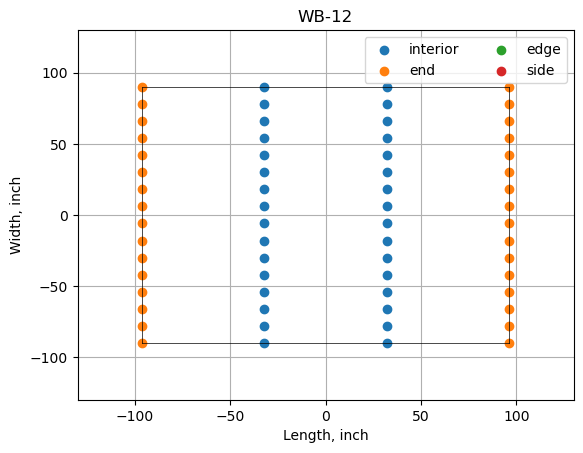

In [51]:
# WB 12 
interior_x, interior_y = support_group(2,16, (5*12)+4, 12) #purlin
end_x, end_y = support_group(2,16,12*16,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-12')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()


In [83]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}


L = 16 
Ls = (5*12)+4
lamda = 1/(1+(Ls/135)**2)
x_load, y_load = -L*12/2 , 96   # in
delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3
#lamda = 1 
strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/1.577))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/1.046))

Iter   0 | F = 5.192744e-01 | IC = (-0.00, -85.21)
Iter  10 | F = 3.617957e-02 | IC = (-0.00, -47.54)
Iter  20 | F = 1.038554e-02 | IC = (-0.00, -46.35)
Iter  30 | F = 2.994289e-03 | IC = (-0.00, -46.02)
Converged at iteration 39, F = 9.7801e-04
Shear strength =  16.36 kips
Shear strength =   1.02 kips/ft
ICM/EXP = 0.65 
ICM/AISI = 0.98 


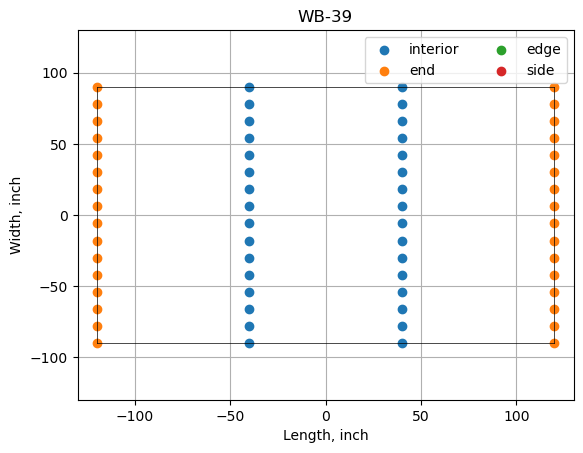

In [87]:
#WB 39, 

interior_x, interior_y = support_group(2,16, (12*6)+8, 12) #purlin
end_x, end_y = support_group(2,16,12*20,12)
edge_x,edge_y = [],[]
side_x,side_y = [],[]

plt.scatter(interior_x,interior_y, label = 'interior')
plt.scatter(end_x,end_y, label='end')
plt.scatter(edge_x,edge_y,label='edge')
plt.scatter(side_x,side_y,label='side')
plt.title('WB-39')
plt.plot([end_x[0],end_x[0]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[0],end_x[-1]],[interior_y[0],interior_y[0]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[0]],[interior_y[-1],interior_y[-1]], c='k', linewidth=0.5)
plt.plot([end_x[-1],end_x[-1]],[interior_y[-1],interior_y[0]], c='k', linewidth=0.5)


plt.xlim(-130,130)
plt.ylim(-130,130)
plt.xlabel('Length, inch')
plt.ylabel('Width, inch')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

In [95]:
curves = {1:raw1, 2:raw2, 3:raw3} # dictionary for the raw data 
x_coord = interior_x + end_x + edge_x + side_x
y_coord = interior_y + end_y + edge_y + side_y

x_coord = np.array(x_coord, dtype=float)
y_coord = np.array(y_coord, dtype=float)

fastener_types = (
    ["InteriorArc"] * len(interior_x) +
    ["EndArc"] * len(end_x) +
    ["EdgeArc"]     * len(edge_x) +
    ["SideScrew"]   * len(side_x)
)




screw_params = {
    'Ke': 0,      # kip/in
    'Ks': 0,
    'Kc': 0,
    'Kr': 0,
    'dy': 0,     # in
    'dc': 0,
    'dr': 0,
    'df': 0,
    'Fc': 0        # kip (≈ F_c)
}

Ls = (6*12)+8
lamda = 1/(1+(Ls/135)**2)
L = 16 
x_load, y_load = -L*12/2 , 96   # in



delta_max = 0.2 #in #0.15 for raw2 #0.14raw 3

strength = ICM1(x_load, y_load, x_coord, y_coord, fastener_types, 3, screw_params,delta_max,lamda)
print('Shear strength = {:6.2f} kips'.format(strength[1]))
print('Shear strength = {:6.2f} kips/ft'.format(strength[1]/L))
print('ICM/EXP = {:4.2f} '.format(strength[1]/L/0.738))
print('ICM/AISI = {:4.2f} '.format(strength[1]/L/0.754))

Iter   0 | F = 4.934347e-01 | IC = (-0.00, -115.21)
Iter  10 | F = 2.949445e-01 | IC = (-0.00, -34.79)
Iter  20 | F = 2.965272e-01 | IC = (-0.00, -34.72)
Iter  30 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  40 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  50 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  60 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  70 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  80 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter  90 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 100 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 110 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 120 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 130 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 140 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 150 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 160 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 170 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 180 | F = 2.965278e-01 | IC = (-0.00, -34.72)
Iter 190 | F = 2.965278e-01 | 